In [ ]:
!pip install requests -- quiet

ERROR: Could not find a version that satisfies the requirement quiet (from versions: none)
ERROR: No matching distribution found for quiet


In [ ]:
import pandas as pd
import requests
import time

### 1 - Pré-processamento

In [ ]:
# Utilizando regex para mascarar informações sensíveis de acordo com a LGPD

df_geral = pd.read_csv("amostrasTeste-fixed.csv")
definitions_impost_ipva = "definitions_impostos_ipva_fixed.txt"
definitions_impost_icms = "definitions_impostos_icms_fixed.txt"
reforco_perguntas_ipva = "reforco_perguntas_ipva_fixed.txt"
reforco_perguntas_icms = "reforco_perguntas_icms_fixed.txt"

In [ ]:
df_geral = df_geral[["mensagem", "assunto"]]

In [ ]:
df_geral.head()

,mensagem,assunto
0,Boa tarde! Sou do escritorio de contabilidade...,Arrecadação - ICMS
1,efetuaram um pagamento em duplicidade do ICSM....,Arrecadação - ICMS
2,Dados da Solicitação Solicitante: MANOEL DE A...,Imposto sobre Propriedade de Veículos Automoto...
3,"Boa tarde, não consegui efetuar o pagamento do...",Imposto sobre Propriedade de Veículos Automoto...
4,preciso do boleto para pagamento do veiculo PN...,Imposto sobre Propriedade de Veículos Automoto...


In [ ]:
import re
def mascarar_dados_sensiveis(texto):
    """Substitui informações sensíveis por placeholders."""

    padroes = {
        "<CPF>": r"\b\d{3}\.?\d{3}\.?\d{3}-?\d{2}\b",
        "<CNPJ>": r"\b\d{2}\.?\d{3}\.?\d{3}/?\d{4}-?\d{2}\b",
        "<RG>": r"\b\d{7,10}\b",
        "<PLACA>": r"\b[A-Z]{3}-?\d{4}\b|\b[A-Z]{3}\d[A-Z]\d{2}\b",
        "<RENAVAM>": r"\b\d{9,11}\b",
        "<CHASSI>": r"\b[A-HJ-NPR-Z0-9]{17}\b"
    }

    for placeholder, regex in padroes.items():
        texto = re.sub(regex, placeholder, texto, flags=re.IGNORECASE)

    return texto

In [ ]:
# Exemplo de uso no dataframe
df_geral["mensagem"] = df_geral["mensagem"].apply(mascarar_dados_sensiveis)

In [ ]:
def processar_txt_para_dataframe(nome_arquivo):
    dados = []

    with open(nome_arquivo, "r", encoding="utf-8") as f:
        for linha in f:
            linha = linha.strip()
            if ":" in linha:
                assunto, mensagem = linha.split(":", 1)
                assunto = assunto.strip()
                mensagem = mensagem.strip()
                mensagem = mascarar_dados_sensiveis(mensagem)
                dados.append({"assunto": assunto, "mensagem": mensagem})

    return pd.DataFrame(dados)

In [ ]:
arquivos = {
    "df_ipva": "definitions_impostos_ipva_fixed.txt",
    "df_icms": "definitions_impostos_icms_fixed.txt",
    "df_reforco_ipva": "reforco_perguntas_ipva_fixed.txt",
    "df_reforco_icms": "reforco_perguntas_icms_fixed.txt"
}


dfs = {nome: processar_txt_para_dataframe(arquivo) for nome, arquivo in arquivos.items()}

In [ ]:
print(dfs["df_icms"].head())

                        assunto  \
0  Legislação Tributária - ICMS   
1  Legislação Tributária - ICMS   
2  Legislação Tributária - ICMS   
3  Legislação Tributária - ICMS   
4  Legislação Tributária - ICMS   

                                            mensagem  
0  ICMS incide sobre a circulação de mercadorias ...  
1  ICMS é cobrado em todas as fases de circulação...  
2  ICMS é cobrado sobre serviços de transporte, c...  
3  ICMS incide circulação mercadorias, serviços t...  
4  Substituição tributária facilita recolhimento ...  


In [ ]:
df_ipva = processar_txt_para_dataframe("definitions_impostos_ipva_fixed.txt")
df_icms = processar_txt_para_dataframe("definitions_impostos_icms_fixed.txt")
df_reforco_ipva = processar_txt_para_dataframe("reforco_perguntas_ipva_fixed.txt")
df_reforco_icms = processar_txt_para_dataframe("reforco_perguntas_icms_fixed.txt")

In [ ]:
df_ipva.head()

,assunto,mensagem
0,Imposto sobre Propriedade de Veículos Automoto...,IPVA é um tributo estadual anual que incide so...
1,Imposto sobre Propriedade de Veículos Automoto...,O valor do IPVA é calculado com base no valor ...
2,Imposto sobre Propriedade de Veículos Automoto...,O pagamento do IPVA é obrigatório e deve ser f...
3,Imposto sobre Propriedade de Veículos Automoto...,O pagamento do IPVA é necessário para a renova...
4,Imposto sobre Propriedade de Veículos Automoto...,"O IPVA pode ser parcelado em até três vezes, d..."


In [ ]:
df_ipva["mensagem"] = df_ipva["mensagem"].apply(mascarar_dados_sensiveis)
df_icms["mensagem"] = df_icms["mensagem"].apply(mascarar_dados_sensiveis)
df_reforco_ipva["mensagem"] = df_reforco_ipva["mensagem"].apply(mascarar_dados_sensiveis)
df_reforco_icms["mensagem"] = df_reforco_icms["mensagem"].apply(mascarar_dados_sensiveis)

In [ ]:
df_geral.to_csv("dados_processados.csv", index=False)
df_ipva.to_csv("definitions_impostos_ipva_fixed_mascarado.csv", index=False)
df_icms.to_csv("definitions_impostos_icms_fixed_mascarado.csv", index=False)
df_reforco_ipva.to_csv("reforco_perguntas_ipva_fixed_mascarado.csv", index=False)
df_reforco_icms.to_csv("reforco_perguntas_icms_fixed_mascarado.csv", index=False)

print("Exportação concluída! 🚀")

Exportação concluída! 🚀


### 2 - PLN

In [ ]:
caminho_arquivo = "dados_processados.csv"
df_MENSAGENS = pd.read_csv(caminho_arquivo)
df_MENSAGENS = df_MENSAGENS[["mensagem", "assunto"]]

In [ ]:
arquivos_csv = ["definitions_impostos_ipva_fixed_mascarado.csv",
                "definitions_impostos_icms_fixed_mascarado.csv",
                "reforco_perguntas_ipva_fixed_mascarado.csv",
                "reforco_perguntas_icms_fixed_mascarado.csv"]

In [ ]:
amostras = []

for arquivo in arquivos_csv:
    df_temp = pd.read_csv(arquivo)
    rotulos_unicos = df_temp["assunto"].unique()

    for rotulo in rotulos_unicos:
        amostra = df_temp[df_temp["assunto"] == rotulo].sample(n=1)
        amostras.append(amostra)
df_EXEMPLOS = pd.concat(amostras, ignore_index=True)

In [ ]:
print(len(df_EXEMPLOS))

10


In [ ]:
print(len(df_MENSAGENS))

45


In [ ]:
print(df_EXEMPLOS["assunto"].value_counts())


assunto
Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais    2
Legislação Tributária - IPVA                                                   2
Isenção de IPVA                                                                2
Legislação Tributária - ICMS                                                   2
Arrecadação - ICMS                                                             2
Name: count, dtype: int64


In [ ]:
API_KEY = "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"

In [ ]:
API_URL = "https://openrouter.ai/api/v1/chat/completions"

In [ ]:
mensagens = df_MENSAGENS["mensagem"].tolist()

In [ ]:
mensagens[12]

'preciso do boleto para pagamento do veiculo <PLACA> renavam: <CPF>'

In [ ]:
categorias = """
1. Legislação Tributária - ICMS
2. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
3. Arrecadação - ICMS
4. Legislação Tributária - IPVA
5. Isenção de IPVA
"""

In [ ]:
mensagens_formatadas = "\n".join([f"Mensagem {i+1}: {msg}" for i, msg in enumerate(mensagens)])

In [ ]:
print(len(df_EXEMPLOS))

10


In [ ]:
exemplos_formatados = "\n\n".join(
    [
        f"Exemplo {i+1}:\nMensagem: \"{row['mensagem']}\"\nClassificação: {row['assunto']}"
        for i, row in df_EXEMPLOS.iterrows()
    ]
)

In [ ]:
mensagens_formatadas

'Mensagem 1: Boa tarde!  Sou do escritorio de contabilidade de uma empresa de SP, localizada no municipio de Santo Andre.  O financeiro deles efetuou o pagamento de uma guia em duplicidade. ICMS ST de nao contribuinte.  Como faço para restituir esse valor?\nMensagem 2: efetuaram um pagamento em duplicidade do ICSM.  Tem como restituir esse valor?  Fico no aguardo\nMensagem 3: Dados da Solicitação  Solicitante: MANOEL DE ALCANTARA  Data da Solicitação: 26/06/2023  Assunto: Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais    Mensagem: Boa tarde, fui imprimir o CRLV digital do meu veículo e consta que tenho um IPVA em aberto plea SER mas, não tem débito. \nMensagem 4: Boa tarde, não consegui efetuar o pagamento do IPVA /2022 e solicito informar como faço para imprimir o referido boleto para pagamento? informo ainda que consegui pagar o licenciamento do ano 2022 no Site do Detran sò não encontro o IPVA 2022.  Desde já agradeço a atenção,\nMensagem 5: preciso do b

In [ ]:
exemplos_formatados

'Exemplo 1:\nMensagem: "O IPVA pode ser pago em parcela única ou em parcelas"\nClassificação: Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais\n\nExemplo 2:\nMensagem: "Valor pago em dobro será restituído."\nClassificação: Legislação Tributária - IPVA\n\nExemplo 3:\nMensagem: "Em alguns estados, veículos com mais de 20 anos de fabricação são isentos do pagamento do IPVA."\nClassificação: Isenção de IPVA\n\nExemplo 4:\nMensagem: "ICMS é cobrado em todas as fases de circulação de mercadorias, desde a produção até a venda final."\nClassificação: Legislação Tributária - ICMS\n\nExemplo 5:\nMensagem: "efetuar o pagamento do ICMS devido para evitar multas"\nClassificação: Arrecadação - ICMS\n\nExemplo 6:\nMensagem: "Não consigo emitir o boleto do IPVA para o meu carro, o que devo fazer?"\nClassificação: Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais\n\nExemplo 7:\nMensagem: "Quais os motivos para indeferimento de isenção de IPVA?"\nClas

In [ ]:
categorias

'\n1. Legislação Tributária - ICMS\n2. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais\n3. Arrecadação - ICMS\n4. Legislação Tributária - IPVA\n5. Isenção de IPVA\n'

In [ ]:
prompt = f"""
Você é um modelo que classifica mensagens nas seguintes categorias:

{categorias}

Agora, classifique todas as 45 mensagens abaixo de acordo com a categoria. Responda APENAS com as categorias, e na mesma ordem em que as mensagens são apresentadas, sem nenhuma mensagem adicional.

{mensagens_formatadas}
"""

In [ ]:
headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}

data = {
    "model": "meta-llama/llama-3.3-70b-instruct:free",
    "messages": [{"role": "user", "content": prompt}],
    "temperature": 0.0
}

response = requests.post(API_URL, headers=headers, json=data)

if response.status_code == 200:
    try:
        resultado = response.json()["choices"][0]["message"]["content"].strip()

        print("Classificação das mensagens:")
        print(resultado)

        classificacoes_modelo = [linha.strip() for linha in resultado.split("\n") if linha.strip()]

        print("\nLista de classificações:")
        print(classificacoes_modelo)
    except KeyError:
        print(f"Erro: Estrutura inesperada na resposta: {response.json()}")
else:
    print(f"Erro: {response.status_code} - {response.text}")

Classificação das mensagens:
1. Legislação Tributária - ICMS
2. Legislação Tributária - ICMS
3. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
4. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
5. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
6. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
7. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
8. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
9. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
10. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
11. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
12. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
13. Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais
14. Imposto sobre Propriedade de V

In [ ]:
print(len(classificacoes_modelo))

45


In [ ]:
df_eval = df_MENSAGENS[["mensagem", "assunto"]]

In [ ]:
df_eval.head()

,mensagem,assunto
0,Boa tarde! Sou do escritorio de contabilidade...,Arrecadação - ICMS
1,efetuaram um pagamento em duplicidade do ICSM....,Arrecadação - ICMS
2,Dados da Solicitação Solicitante: MANOEL DE A...,Imposto sobre Propriedade de Veículos Automoto...
3,"Boa tarde, não consegui efetuar o pagamento do...",Imposto sobre Propriedade de Veículos Automoto...
4,preciso do boleto para pagamento do veiculo <P...,Imposto sobre Propriedade de Veículos Automoto...


In [ ]:
# assert len(classificacoes_modelo) == len(df_eval), "A lista de classificações_modelo deve ter o mesmo número de itens que o DataFrame!"

# Se houver 46 itens, significa que o primeiro item é uma mensagem extra, então removemos
if len(classificacoes_modelo) == 46:
    classificacoes_modelo = classificacoes_modelo[1:]

# Agora garantimos que as listas estejam alinhadas
assert len(classificacoes_modelo) == len(df_eval), "Erro após a remoção: os tamanhos ainda não correspondem!"

In [ ]:
df_eval["assunto_previsto"] = classificacoes_modelo

In [ ]:
df_eval["veredito"] = df_eval["assunto"] == df_eval["assunto_previsto"]

In [ ]:
df_eval.head()

,mensagem,assunto,assunto_previsto,veredito
0,Boa tarde! Sou do escritorio de contabilidade...,Arrecadação - ICMS,1. Legislação Tributária - ICMS,False
1,efetuaram um pagamento em duplicidade do ICSM....,Arrecadação - ICMS,2. Legislação Tributária - ICMS,False
2,Dados da Solicitação Solicitante: MANOEL DE A...,Imposto sobre Propriedade de Veículos Automoto...,3. Imposto sobre Propriedade de Veículos Autom...,False
3,"Boa tarde, não consegui efetuar o pagamento do...",Imposto sobre Propriedade de Veículos Automoto...,4. Imposto sobre Propriedade de Veículos Autom...,False
4,preciso do boleto para pagamento do veiculo <P...,Imposto sobre Propriedade de Veículos Automoto...,5. Imposto sobre Propriedade de Veículos Autom...,False


In [ ]:
import re

In [ ]:
df_eval["assunto_previsto"] = df_eval["assunto_previsto"].apply(
    lambda x: re.sub(r"^[\*\d+\.\s]*", "", x)
)


In [ ]:
df_eval["veredito"] = df_eval["assunto"] == df_eval["assunto_previsto"]

In [ ]:
df_eval.head()

,mensagem,assunto,assunto_previsto,veredito
0,Boa tarde! Sou do escritorio de contabilidade...,Arrecadação - ICMS,Legislação Tributária - ICMS,False
1,efetuaram um pagamento em duplicidade do ICSM....,Arrecadação - ICMS,Legislação Tributária - ICMS,False
2,Dados da Solicitação Solicitante: MANOEL DE A...,Imposto sobre Propriedade de Veículos Automoto...,Imposto sobre Propriedade de Veículos Automoto...,True
3,"Boa tarde, não consegui efetuar o pagamento do...",Imposto sobre Propriedade de Veículos Automoto...,Imposto sobre Propriedade de Veículos Automoto...,True
4,preciso do boleto para pagamento do veiculo <P...,Imposto sobre Propriedade de Veículos Automoto...,Imposto sobre Propriedade de Veículos Automoto...,True


In [ ]:
erros = df_eval[df_eval["veredito"] == False]


total_mensagens = len(df_eval)


total_erros = len(erros)


porcentagem_erros = (total_erros / total_mensagens) * 100
porcentagem_acertos = 100 - porcentagem_erros


print(f"Total de mensagens: {total_mensagens}")
print(f"Total de erros: {total_erros} ({porcentagem_erros:.2f}%)")
print(f"Total de acertos: {total_mensagens - total_erros} ({porcentagem_acertos:.2f}%)")


print("Classificações incorretas:")
print(erros)

Total de mensagens: 45
Total de erros: 13 (28.89%)
Total de acertos: 32 (71.11%)
Classificações incorretas:
                                             mensagem  \
0   Boa tarde!  Sou do escritorio de contabilidade...   
1   efetuaram um pagamento em duplicidade do ICSM....   
28  Prezados bom dia!  Somos umas empresa do setor...   
31  Prezados, bom dia!    Gostaria de tirar uma dú...   
33  Prezados, boa tarde!   Na hipótese de um hospi...   
37  Boa tarde!    Estou tentando transferir veícul...   
38  Abri uma chama sobre um Ipva em aberto e gosta...   
39  Bom dia.     Estou emitindo o DAR - IPVA, prim...   
40            Como transferir IPVA para outro estado?   
41  Onde solicitar ressarcimento de IPVA pago em d...   
42  Como proceder com IPVA atrasado do veículo com...   
43                      Como pagar IPVA com desconto?   
44  Paguei o boleto duas vezes, como faço para sol...   

                         assunto  \
0             Arrecadação - ICMS   
1             Arrecad

In [ ]:
df_eval.head()

,mensagem,assunto,assunto_previsto,veredito
0,Boa tarde! Sou do escritorio de contabilidade...,Arrecadação - ICMS,Legislação Tributária - ICMS,False
1,efetuaram um pagamento em duplicidade do ICSM....,Arrecadação - ICMS,Legislação Tributária - ICMS,False
2,Dados da Solicitação Solicitante: MANOEL DE A...,Imposto sobre Propriedade de Veículos Automoto...,Imposto sobre Propriedade de Veículos Automoto...,True
3,"Boa tarde, não consegui efetuar o pagamento do...",Imposto sobre Propriedade de Veículos Automoto...,Imposto sobre Propriedade de Veículos Automoto...,True
4,preciso do boleto para pagamento do veiculo <P...,Imposto sobre Propriedade de Veículos Automoto...,Imposto sobre Propriedade de Veículos Automoto...,True


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
labels = {
    "Legislação Tributária - ICMS": "Class 1",
    "Imposto sobre Propriedade de Veículos Automotores-IPVA - Informações Gerais": "Class 2",
    "Arrecadação - ICMS": "Class 3",
    "Legislação Tributária - IPVA": "Class 4",
    "Isenção de IPVA": "Class 5"
}

# Convertendo as labels para uma lista
label_list = list(labels.values())


In [ ]:
# Gerando a matriz de confusão com as labels substituídas
matriz = confusion_matrix(df_eval['assunto'].map(labels), df_eval['assunto_previsto'].map(labels), labels=label_list)

In [ ]:
# Criando um DataFrame para a matriz de confusão com as novas labels
matriz_confusao_df_zero = pd.DataFrame(matriz,
                                  index=label_list,
                                  columns=label_list)

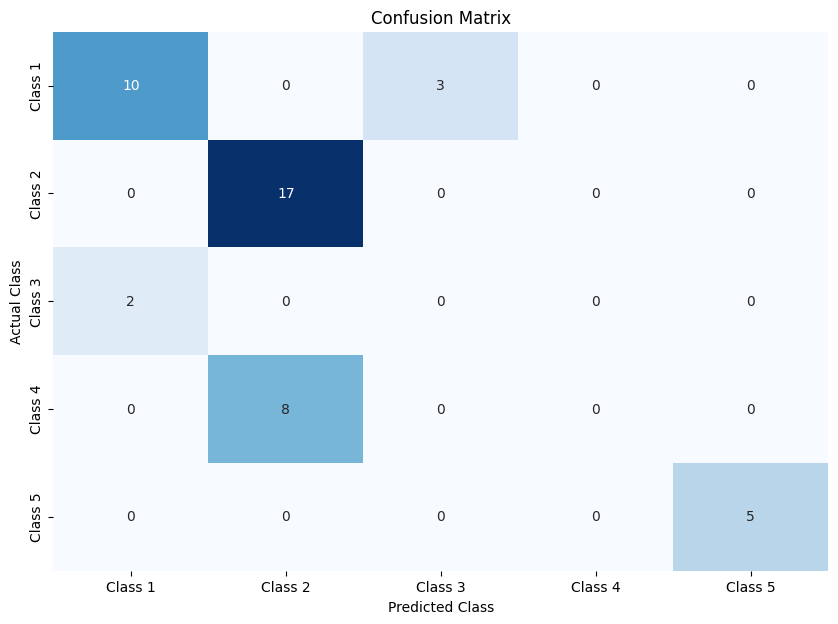

In [ ]:
# Exibindo a matriz de confusão com uma visualização gráfica
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_confusao_df_zero, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()

In [ ]:
# Filtrando os erros (onde o valor real e o previsto são diferentes)
df_erros = df_eval[df_eval['assunto'] != df_eval['assunto_previsto']]

# Exibindo o DataFrame de erros (apenas as colunas relevantes)
df_erros_reduzido = df_erros[['mensagem', 'assunto', 'assunto_previsto']]

# Salvando o novo DataFrame com os erros em um arquivo CSV
df_erros_reduzido.to_csv('erros_classificacao_zero.csv', index=False)

print("Arquivo com erros salvo como 'erros_classificacao_zero.csv'. 🚀")

Arquivo com erros salvo como 'erros_classificacao_zero.csv'. 🚀


In [ ]:
df_erros.head(15)

,mensagem,assunto,assunto_previsto,veredito
0,Boa tarde! Sou do escritorio de contabilidade...,Arrecadação - ICMS,Legislação Tributária - ICMS,False
1,efetuaram um pagamento em duplicidade do ICSM....,Arrecadação - ICMS,Legislação Tributária - ICMS,False
28,Prezados bom dia! Somos umas empresa do setor...,Legislação Tributária - ICMS,Arrecadação - ICMS,False
31,"Prezados, bom dia! Gostaria de tirar uma dú...",Legislação Tributária - ICMS,Arrecadação - ICMS,False
33,"Prezados, boa tarde! Na hipótese de um hospi...",Legislação Tributária - ICMS,Arrecadação - ICMS,False
37,Boa tarde! Estou tentando transferir veícul...,Legislação Tributária - IPVA,Imposto sobre Propriedade de Veículos Automoto...,False
38,Abri uma chama sobre um Ipva em aberto e gosta...,Legislação Tributária - IPVA,Imposto sobre Propriedade de Veículos Automoto...,False
39,"Bom dia. Estou emitindo o DAR - IPVA, prim...",Legislação Tributária - IPVA,Imposto sobre Propriedade de Veículos Automoto...,False
40,Como transferir IPVA para outro estado?,Legislação Tributária - IPVA,Imposto sobre Propriedade de Veículos Automoto...,False
41,Onde solicitar ressarcimento de IPVA pago em d...,Legislação Tributária - IPVA,Imposto sobre Propriedade de Veículos Automoto...,False
